In [93]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split
from collections import Counter

In [94]:

transform = transforms.Compose([
    transforms.ToTensor()              #pixel values scaled from [0,255] to [0,1]
])
data_path = "/Users/Nontokozodladla/Desktop/cifar"  

trainset = torchvision.datasets.CIFAR10(   #Training dataset loading
    root=data_path,
    train=True,
    download=False,   
    transform=transform             
)

testset = torchvision.datasets.CIFAR10(  #Testing dataset loading
    root=data_path,
    train=False,
    download=False,  
    transform=transform
)

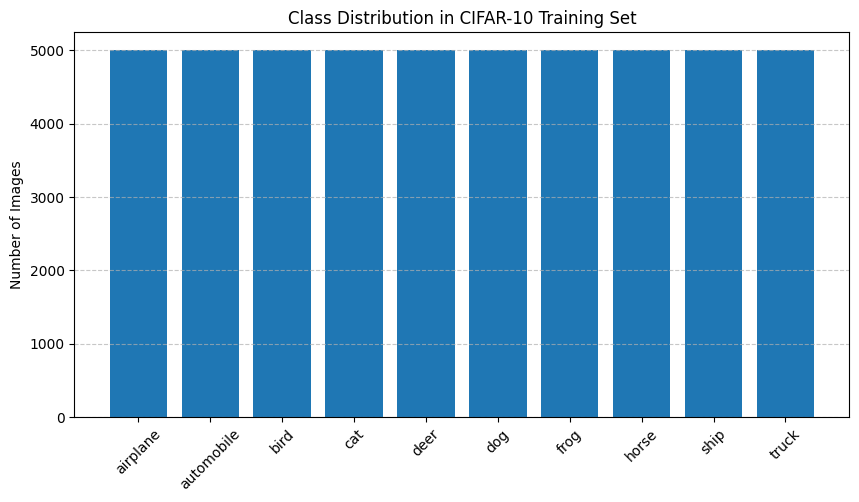

In [95]:
labels = trainset.targets
class_names = trainset.classes

class_counts = Counter(labels)  #How many images belong to each class

plt.figure(figsize=(10,5))
plt.bar(class_names, [class_counts[i] for i in range(10)])

plt.xticks(rotation=45)
plt.title("Class Distribution in CIFAR-10 Training Set")
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


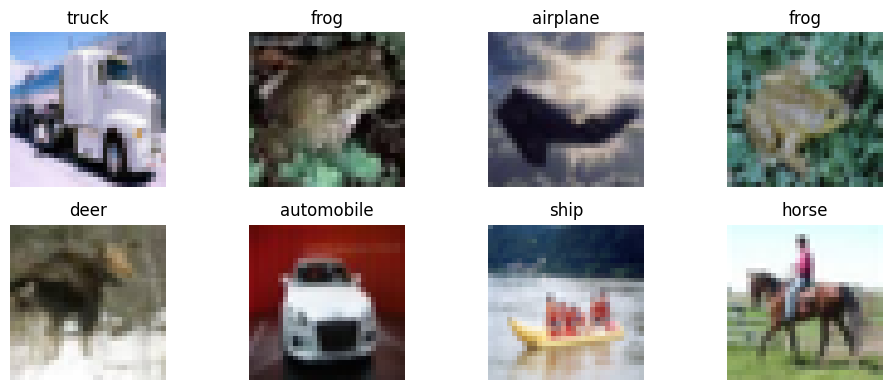

In [96]:
def imshow(img):                               #imshow function to show the images
    img = img.clamp(0,1)
    npimg = img.numpy()                        #Converts tensor to numpy as matplot expects numpy arrays
    plt.imshow(np.transpose(npimg, (1, 2, 0))) #Reorders image dimensions from c,h,w (pytorch) to h,w,c (matplot)
    plt.axis('off')                            #Removes x/y axis ticks for cleaner image display

# Random training images
dataiter = iter(torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True))
images, labels = next(dataiter)

plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()


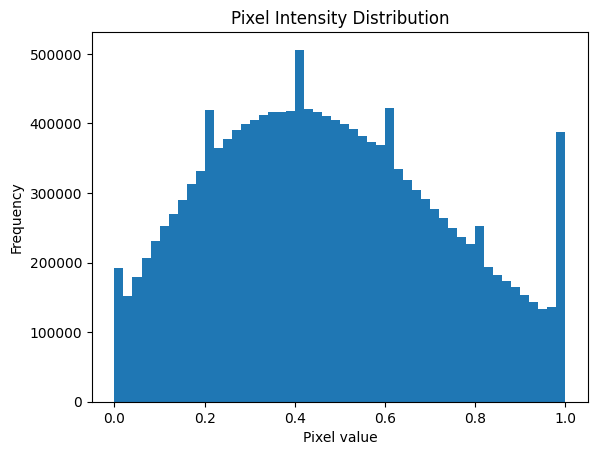

In [97]:
subset_size = 5000 #Analysis size limited to 5000 for speed
pixels = []        #for storing all pixel intensity values

for i in range(subset_size):
    img, _ = trainset[i]
    pixels.extend(img.numpy().flatten())

plt.figure()
plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.show()

In [98]:
img, label = trainset[0]
print("Image shape:", img.shape)

Image shape: torch.Size([3, 32, 32])


In [103]:
#Data loader
# Split training dataset into train and validation sets

train_size = 45000
val_size = 5000

train_dataset, val_dataset = random_split(
    trainset,
    [train_size, val_size]
)

# Create dataloaders

trainloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

valloader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)


In [104]:
class Autoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder (Compresses input image into samller latent representation)
        self.encoder = nn.Sequential(

            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )
# Decoder (Reconstructs the image from compressed repesentation
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                64,
                32,
                3,
                stride=2,
                padding=1,
                output_padding=1  #Upsampling: increase image dimensions
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                32,
                3,
                3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)

        x = self.decoder(x)

        return x

In [105]:
#Model Initialization
model = Autoencoder()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(  #Responsible for updating model weights during training
    model.parameters(),
    lr=0.001
)


In [106]:
#Training loop
train_losses = []
val_losses = []

for epoch in range(20):

# TRAINING
   
    model.train()

    running_train_loss = 0.0

    for images, _ in trainloader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, images)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(trainloader)

    train_losses.append(epoch_train_loss)


# VALIDATION

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, _ in valloader:

            outputs = model(images)

            loss = criterion(outputs, images)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(valloader)

    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1}, "
        f"Train Loss: {epoch_train_loss:.4f}, "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

Epoch 1, Train Loss: 0.0079, Val Loss: 0.0027
Epoch 2, Train Loss: 0.0022, Val Loss: 0.0018
Epoch 3, Train Loss: 0.0016, Val Loss: 0.0014
Epoch 4, Train Loss: 0.0013, Val Loss: 0.0011
Epoch 5, Train Loss: 0.0011, Val Loss: 0.0009
Epoch 6, Train Loss: 0.0009, Val Loss: 0.0008
Epoch 7, Train Loss: 0.0008, Val Loss: 0.0009
Epoch 8, Train Loss: 0.0007, Val Loss: 0.0007
Epoch 9, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 10, Train Loss: 0.0006, Val Loss: 0.0006
Epoch 11, Train Loss: 0.0006, Val Loss: 0.0006
Epoch 12, Train Loss: 0.0006, Val Loss: 0.0005
Epoch 13, Train Loss: 0.0005, Val Loss: 0.0005
Epoch 14, Train Loss: 0.0005, Val Loss: 0.0005
Epoch 15, Train Loss: 0.0005, Val Loss: 0.0006
Epoch 16, Train Loss: 0.0005, Val Loss: 0.0005
Epoch 17, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 18, Train Loss: 0.0004, Val Loss: 0.0004
Epoch 19, Train Loss: 0.0004, Val Loss: 0.0004
Epoch 20, Train Loss: 0.0004, Val Loss: 0.0004


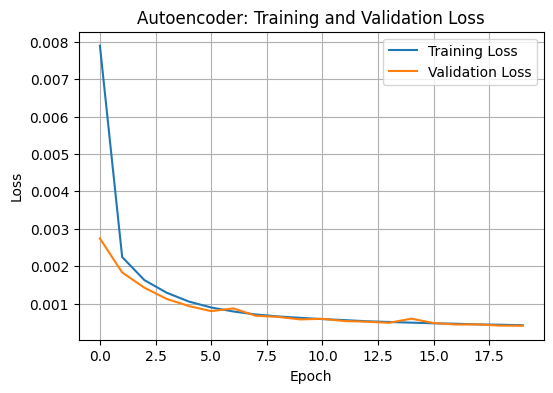

In [109]:
#Loss curve
plt.figure(figsize=(6,4))

plt.plot(train_losses, label="Training Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Autoencoder: Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

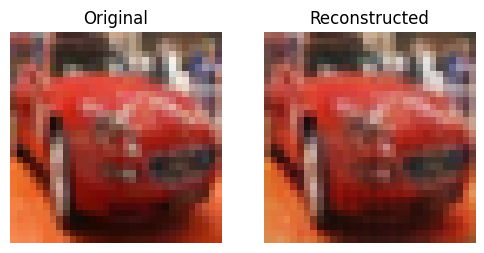

In [108]:
# VISUALIZING RECONSTRUCTION

model.eval()

with torch.no_grad():

    sample, _ = trainset[5]

    sample = sample.unsqueeze(0)

    reconstructed = model(sample)

    # Prepare images
original = sample.squeeze().permute(1,2,0)

recon = reconstructed.squeeze().permute(1,2,0)


# Plot comparison
plt.figure(figsize=(6,3))


# Original image
plt.subplot(1,2,1)

plt.title("Original")

plt.imshow(original)

plt.axis('off')

# Reconstructed image
plt.subplot(1,2,2)

plt.title("Reconstructed")

plt.imshow(recon)

plt.axis('off')


plt.show()
